In [1]:
import numpy as np

path0 = './'
filename = 'syntax_matched_sentences.txt'
threshold = 0.4  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 5:
            sentence1, sentence2, tags1, tags2, word_overlap = parts
            try:
                if float(word_overlap) < threshold and tags1 == tags2:
                    data.append((sentence1, sentence2, tags1, word_overlap))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(f'{len(data)=}')
print(data[-1])

# removing entries with tag counts less than 5
from collections import Counter
tag_counts = Counter(tags for _, _, tags, _ in data)
data = [entry for entry in data if tag_counts[entry[2]] > 5]

print(f"Filtered size: {len(data)}")

len(data)=2369
('The old tradition and a custom changed gradually', 'The soft pillow and a blanket lay comfortably', 'DT JJ NN CC DT NN VBD RB', '0.375')
Filtered size: 2098


In [2]:
# Export sentences from the filtered dataset to sentences0.txt and sentences1.txt

sentences0 = [entry[0] for entry in data]
sentences1 = [entry[1] for entry in data]

with open('sentences0.txt', 'w') as f0:
  for sentence in sentences0:
    f0.write(sentence + '\n')

with open('sentences1.txt', 'w') as f1:
  for sentence in sentences1:
    f1.write(sentence + '\n')

len(unique_tags)=96


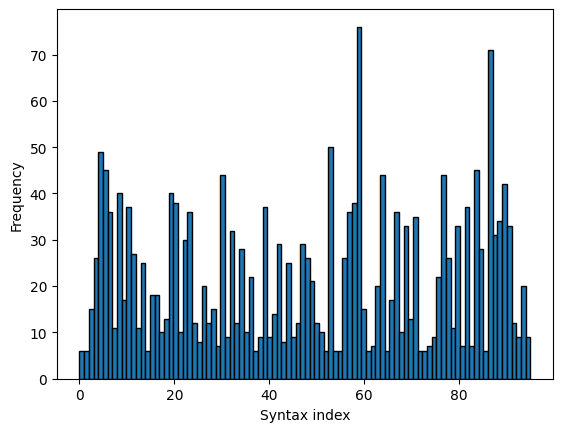

In [3]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1)
# Assign an index to each unique tag in data
unique_tags = sorted(set(entry[2] for entry in data))
tag_to_index = {tag: idx for idx, tag in enumerate(unique_tags)}

# Get the list of tag indices for all entries in data
tag_indices = [tag_to_index[entry[2]] for entry in data]

# Plot histogram of tag indices
ax.hist(tag_indices, bins=len(unique_tags), edgecolor='black')
plt.xlabel('Syntax index')
plt.ylabel('Frequency')
# plt.title('Histogram of syntax structures in data')
fig.savefig('syntax_pos_frequencies.pdf', bbox_inches='tight')
print(f'{len(unique_tags)=}')
plt.show()

In [4]:
np.savetxt('group_ids.txt',tag_indices,fmt='%d')

In [5]:
# Check if each sentence in sentences0 is also present in sentences1
sentences1_set = set(sentences1)
sentences0_in_1 = [sentence in sentences1_set for sentence in sentences0]

# Print summary
num_present = sum(sentences0_in_1)
print(f"{num_present} out of {len(sentences0)} sentences from sentences0.txt are present in sentences1.txt")

2063 out of 2098 sentences from sentences0.txt are present in sentences1.txt


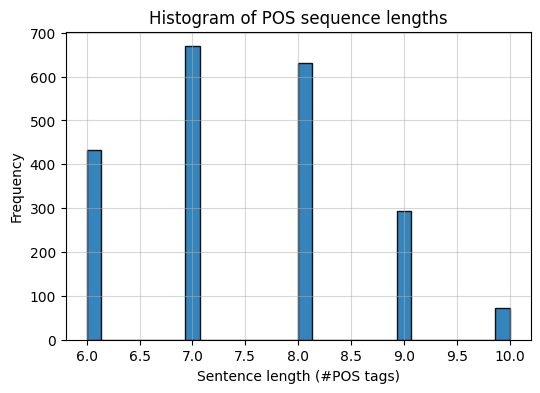

In [6]:
import matplotlib.pyplot as plt

# Compute lengths (number of POS tags per sentence)
lengths = [len(entry[2].split()) for entry in data]

# Plot histogram
fig,ax = plt.subplots(figsize=(6, 4))
plt.hist(lengths, bins=30, edgecolor='black', alpha=0.9)
plt.xlabel('Sentence length (#POS tags)')
plt.ylabel('Frequency')
plt.title('Histogram of POS sequence lengths')
plt.grid(alpha=0.5)
fig.savefig(f'length_pos_frequencies.pdf',bbox_inches='tight')
plt.show()


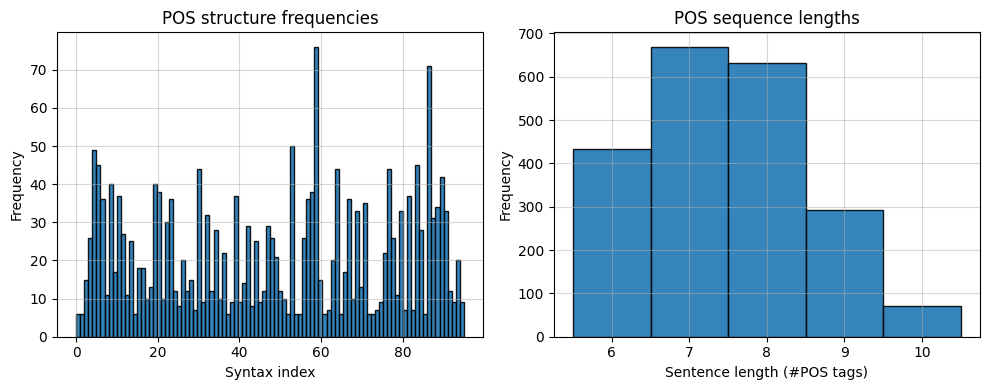

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data prep ---
unique_tags = sorted(set(entry[2] for entry in data))
tag_to_index = {tag: idx for idx, tag in enumerate(unique_tags)}
tag_indices = [tag_to_index[entry[2]] for entry in data]
lengths = [len(entry[2].split()) for entry in data]

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Left: POS structure frequencies
ax[0].hist(tag_indices, bins=len(unique_tags), edgecolor='black', alpha=0.9)
ax[0].set_xlabel('Syntax index')
ax[0].set_ylabel('Frequency')
ax[0].set_title('POS structure frequencies')
ax[0].grid(alpha=0.5)

# Right: Sentence length histogram (integer bins)
bins = np.arange(min(lengths) - 0.5, max(lengths) + 1.5, 1)
ax[1].hist(lengths, bins=bins, edgecolor='black', alpha=0.9)
ax[1].set_xlabel('Sentence length (#POS tags)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('POS sequence lengths')
ax[1].grid(alpha=0.5)

fig.tight_layout()
fig.savefig('syntax_pos_statistics.pdf', bbox_inches='tight')
plt.show()


In [8]:
word_overlaps = np.array([float(entry[3]) for entry in data], dtype=float)
print(f"Average word overlap: {word_overlaps.mean():.2f}")
print(f"Standard deviation: {word_overlaps.std():.2f}")


Average word overlap: 0.19
Standard deviation: 0.10


### Semantic ablation

I have to filter syntax pairs for which I have their semantic vectors

In [ ]:
# filenames
file_syn = "sentences0.txt"
file_sem = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sentences0.txt"
syn_ids_with_sem_path = "syn_ids_with_sem.txt" # which sentences in the syntax file are present in the semantic file.
sem_centers_ids_path = "sem_centers_ids.txt" # where in the semantic file those sentences are located.

# read files
with open(file_syn, "r", encoding="utf-8") as f:
    sentences_syn = [line.strip() for line in f]

with open(file_sem, "r", encoding="utf-8") as f:
    sentences_sem = [line.strip() for line in f]

print(f'{len(sentences_syn)=}')
print(f'{len(sentences_sem)=}')

# create dictionary mapping sentence -> index in file_sem
sentence_to_index_sem = {s: i for i, s in enumerate(sentences_sem)}

# find matching indices
syn_ids_with_sem = [i for i, s in enumerate(sentences_syn) if s in sentence_to_index_sem]
sem_ids_for_syn = [sentence_to_index_sem[s] for s in sentences_syn if s in sentence_to_index_sem]

# save file_syn indices
with open(syn_ids_with_sem_path, "w", encoding="utf-8") as f:
    for idx in syn_ids_with_sem:
        f.write(f"{idx}\n")

# save file_sem indices
with open(sem_centers_ids_path, "w", encoding="utf-8") as f:
    for idx in sem_ids_for_syn:
        f.write(f"{idx}\n")

print(f"Saved {len(syn_ids_with_sem)} indices from file_syn to {syn_ids_with_sem_path}")
print(f"Saved {len(sem_ids_for_syn)} indices from file_sem to {sem_centers_ids_path}")


len(sentences_syn)=2098
len(sentences_sem)=2018
Saved 1584 indices from file_syn to syn_ids_with_sem.txt
Saved 1584 indices from file_sem to sem_centers_ids.txt
